# Q7 — Does location affect data completeness?

**Completeness signals.** We use only *platform-provided* signals that actually vary by
location — **listing on Tripadvisor / TheFork, having a website, carrying cuisine tags, and
Google review volume**. We deliberately drop signals that look like completeness but carry
no location information: **photos** (median ≈10 and >90% non-empty *everywhere*) and
**phone numbers** (~84% Google / ~94% Tripadvisor everywhere) are saturated, and
**coordinates** are excluded because we enriched Tripadvisor’s ourselves — they measure our
pipeline, not the platform.

**Scope: Milan only** — the Google seed includes surrounding municipalities (~16% of rows)
which would dominate the “periphery” bucket. Three views: a **completeness map** (1 km
cells coloured by the share of venues with a website), a **distance gradient** from the
Duomo, and a **center-vs-periphery dumbbell**, plus per-quartiere and per-postcode tables.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
rows = run(queries.q7_rows())
rows["km"] = rows.apply(lambda r: distance_to_duomo_km(r["latitude"], r["longitude"]), axis=1)
rows["zone"] = rows.apply(lambda r: classify_center_periphery(r["latitude"], r["longitude"]), axis=1)
rows["neighbourhood"] = rows.apply(lambda r: assign_neighbourhood(r["latitude"], r["longitude"]), axis=1)
geo = rows.dropna(subset=["latitude", "longitude", "km"])
geo = geo[(geo["latitude"] != 0) & (geo["longitude"] != 0)].copy()
# Boolean completeness signals (platform-provided; coordinates are NOT used as a signal \u2014
# we enriched Tripadvisor's, so they would measure our pipeline, not the platform).
geo["has_website"] = (geo["website"].str.len() > 0).astype(int)
geo["has_cuisine"] = (geo["primary_cuisine"].str.len() > 0).astype(int)
geo["ring"] = pd.cut(geo["km"], [0, 1, 2, 4, 8], labels=["0-1", "1-2", "2-4", "4-8"])
print(f"{len(geo)} Milan restaurants with usable coordinates "
      f"({len(rows) - len(geo)} excluded for missing coordinates).")

8448 Milan restaurants with usable coordinates (0 excluded for missing coordinates).


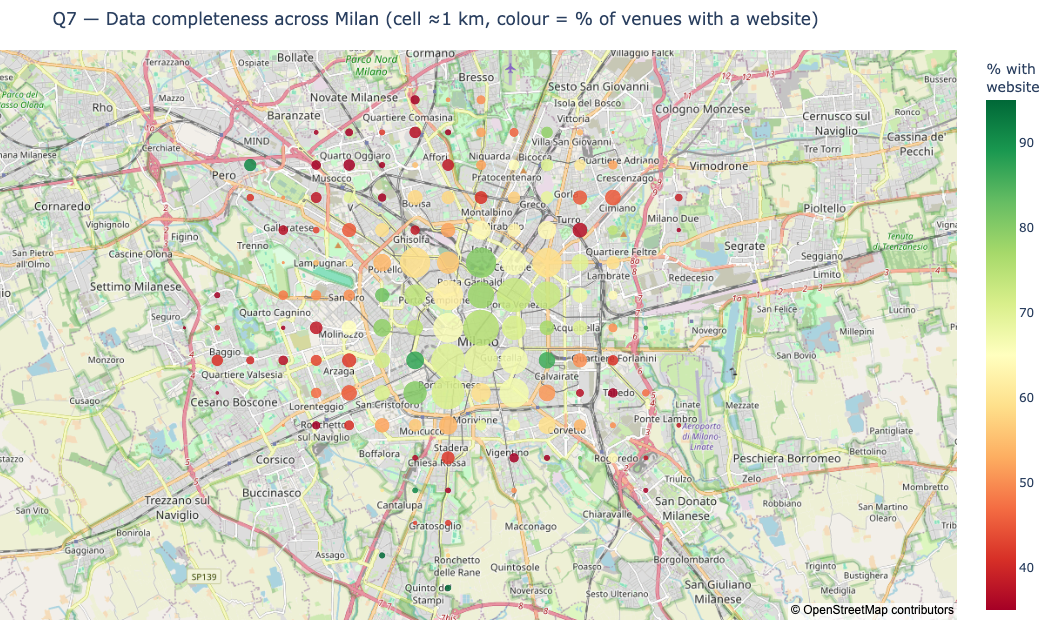

In [3]:
# Completeness MAP — ~1 km grid cells coloured by the share of venues with a website (a
# strong, location-varying signal), sized by venue count. Colour (not point density) is the
# completeness signal, so the centre-bias reads directly off the map.
gmap = geo.assign(glat=(geo["latitude"] / 0.009).round() * 0.009,
                  glon=(geo["longitude"] / 0.013).round() * 0.013)
cell = (gmap.groupby(["glat", "glon"], as_index=False)
        .agg(venues=("has_website", "size"), website=("has_website", "mean")))
cell = cell[cell["venues"] >= 4]
cell["website"] = (cell["website"] * 100).round(0)
fig = px.scatter_map(cell, lat="glat", lon="glon", color="website", size="venues", size_max=26,
    opacity=0.85, color_continuous_scale="RdYlGn", range_color=[35, 95], zoom=10.8,
    center={"lat": 45.466, "lon": 9.19}, map_style="open-street-map", height=720,
    labels={"website": "% with<br>website", "venues": "venues"},
    title="Q7 — Data completeness across Milan (cell ≈1 km, colour = % of venues with a website)")
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()

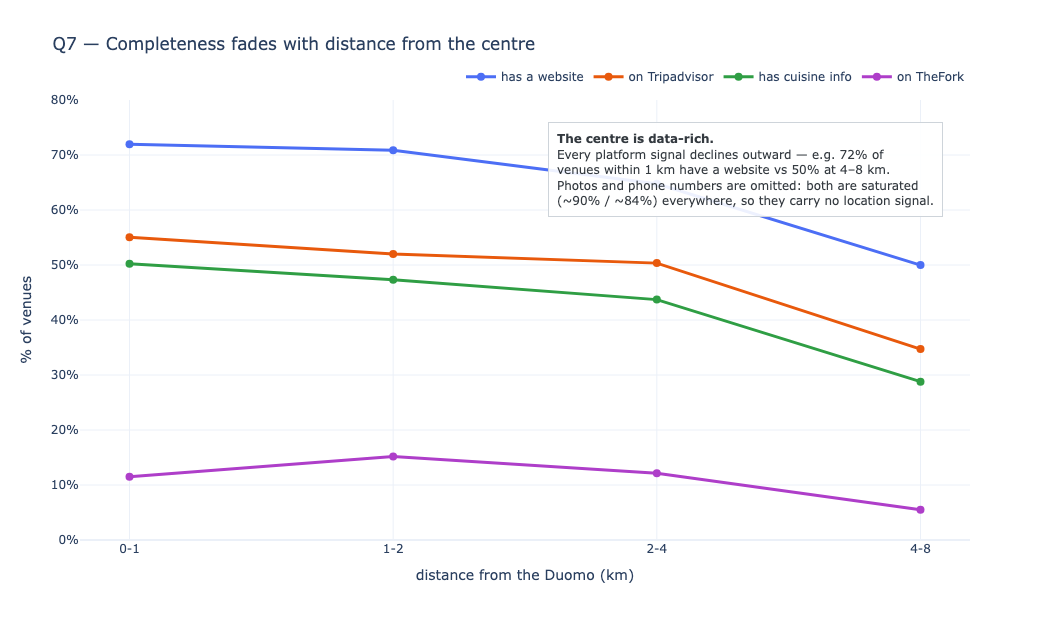

In [4]:
# Completeness fades SMOOTHLY with distance from the Duomo — a gradient, not a hard cut.
_g = geo.dropna(subset=["ring"]).groupby("ring", observed=True)
grad = pd.DataFrame({
    "has a website": 100 * _g["has_website"].mean(),
    "on Tripadvisor": 100 * _g["has_tripadvisor"].mean(),
    "has cuisine info": 100 * _g["has_cuisine"].mean(),
    "on TheFork": 100 * _g["has_thefork"].mean(),
})
gl = grad.reset_index().melt("ring", var_name="signal", value_name="pct")
_sigcol = {"has a website": "#4C6EF5", "on Tripadvisor": "#E8590C",
           "has cuisine info": "#2F9E44", "on TheFork": "#AE3EC9"}
fig = px.line(gl, x="ring", y="pct", color="signal", markers=True, color_discrete_map=_sigcol,
    template="plotly_white",
    labels={"ring": "distance from the Duomo (km)", "pct": "% of venues", "signal": ""},
    title="Q7 — Completeness fades with distance from the centre")
fig.update_traces(line_width=3, marker_size=8)
fig.update_yaxes(range=[0, 80], ticksuffix="%")
fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.add_annotation(
    xref="paper", yref="paper", x=0.97, y=0.95, xanchor="right", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.9)", font=dict(size=12, color="#343A40"),
    text=("<b>The centre is data-rich.</b><br>"
          f"Every platform signal declines outward — e.g. {grad.loc['0-1', 'has a website']:.0f}% of<br>"
          f"venues within 1 km have a website vs {grad.loc['4-8', 'has a website']:.0f}% at 4–8 km.<br>"
          "Photos and phone numbers are omitted: both are saturated<br>"
          "(~90% / ~84%) everywhere, so they carry no location signal."))
fig.show()

In [5]:
def completeness_summary(df):
    return pd.Series({
        "restaurants": len(df),
        "mean_platform_count": round(df["platform_count"].mean(), 2),
        "pct_has_website": round(100 * df["has_website"].mean(), 1),
        "pct_has_cuisine": round(100 * df["has_cuisine"].mean(), 1),
        "pct_on_tripadvisor": round(100 * df["has_tripadvisor"].mean(), 1),
        "pct_on_thefork": round(100 * df["has_thefork"].mean(), 1),
        "median_google_reviews": float(df["google_review_count"].median()),
    })


q7_zone = geo.groupby("zone").apply(completeness_summary, include_groups=False).reset_index()
q7_zone = publish(q7_zone, "q7_completeness_center_periphery",
                  "Q7 — Completeness (website, cuisine, cross-listing, reviews) by center vs periphery.")
q7_zone

,zone,restaurants,mean_platform_count,pct_has_website,pct_has_cuisine,pct_on_tripadvisor,pct_on_thefork,median_google_reviews
0,center,2663.0,1.67,71.2,48.3,53.1,13.9,269.0
1,periphery,5785.0,1.53,58.8,37.1,43.3,9.3,161.0


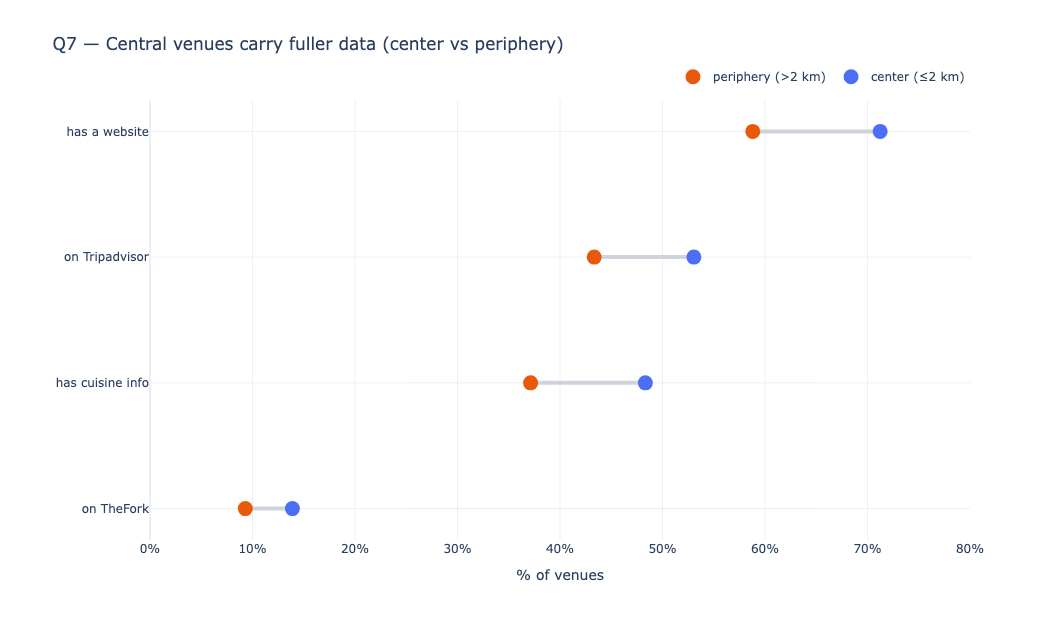

In [6]:
# Center vs periphery as a dumbbell: one row per signal, the gap shown directly. Strong
# signals only (websites, cuisine, cross-listing); photos/phones are saturated and dropped.
_sig = {"has a website": "has_website", "has cuisine info": "has_cuisine",
        "on Tripadvisor": "has_tripadvisor", "on TheFork": "has_thefork"}
_z = geo.groupby("zone")
db = pd.DataFrame({lbl: 100 * _z[col].mean() for lbl, col in _sig.items()}).T.sort_values("center")
fig = go.Figure()
for s in db.index:
    fig.add_trace(go.Scatter(x=[db.loc[s, "periphery"], db.loc[s, "center"]], y=[s, s], mode="lines",
        line=dict(color="#CED4DA", width=4), showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=db["periphery"], y=db.index, mode="markers", name="periphery (>2 km)",
    marker=dict(size=15, color="#E8590C")))
fig.add_trace(go.Scatter(x=db["center"], y=db.index, mode="markers", name="center (≤2 km)",
    marker=dict(size=15, color="#4C6EF5")))
fig.update_layout(template="plotly_white", margin=dict(l=150),
    title="Q7 — Central venues carry fuller data (center vs periphery)",
    xaxis=dict(title="% of venues", ticksuffix="%", range=[0, 80]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.show()

In [7]:
q7_hood = geo.groupby("neighbourhood").apply(completeness_summary, include_groups=False).reset_index()
q7_hood = q7_hood.sort_values("restaurants", ascending=False)
q7_hood = publish(q7_hood, "q7_completeness_neighbourhood",
                  "Q7 — Completeness by popular Milan quartiere vs other.")
q7_hood

,neighbourhood,restaurants,mean_platform_count,pct_has_website,pct_has_cuisine,pct_on_tripadvisor,pct_on_thefork,median_google_reviews
5,other,5450.0,1.53,59.3,37.0,43.0,9.5,165.0
1,duomo,983.0,1.62,70.6,45.7,51.8,9.8,215.5
7,porta_venezia,382.0,1.67,73.3,48.2,52.9,14.4,305.5
6,porta_romana,301.0,1.62,66.1,43.5,47.5,15.0,229.0
8,sempione,281.0,1.66,60.5,42.7,50.5,15.3,180.0
2,isola,278.0,1.78,77.3,54.7,59.7,18.0,312.5
3,loreto,268.0,1.53,57.1,36.6,43.7,9.3,134.0
0,brera,258.0,1.71,67.1,54.7,55.8,15.5,345.0
4,navigli,247.0,1.77,74.5,58.3,62.3,14.2,413.0


In [8]:
q7_postal = publish(run(queries.q7_postal_completeness()), "q7_completeness_by_postal_code",
                    "Q7 — Coverage and completeness by postal code (area proxy).")
q7_postal.head(15)

,postal_code,restaurants,mean_platform_count,pct_on_tripadvisor,pct_on_thefork,pct_has_website,pct_has_cuisine,median_google_reviews
0,20121,591,1.71,56.2,14.9,73.3,52.6,326.0
1,20123,573,1.64,52.7,11.0,71.9,46.1,292.0
2,20154,571,1.63,48.9,14.4,60.1,42.2,203.0
3,20124,509,1.69,52.7,16.7,69.9,49.7,317.0
4,20122,464,1.59,48.7,9.9,65.1,42.5,137.0
5,20129,392,1.66,53.6,12.8,76.3,48.2,270.0
6,20135,353,1.64,49.3,14.7,71.4,44.8,247.0
7,20159,288,1.75,58.7,16.7,68.1,53.5,278.0
8,20144,287,1.86,69.3,17.1,83.6,63.1,339.0
9,20127,248,1.52,46.8,5.2,59.7,34.7,146.0


**Answer (Q7):** Yes — **completeness falls with distance from the centre**, smoothly rather
than at a hard boundary. Central venues (≤2 km from the Duomo) are markedly more likely to
carry a website (71% vs 50%), cuisine tags (48% vs 37%), a Tripadvisor listing (53% vs 43%)
and a TheFork listing, and they have ~1.7× the median Google review volume — see
`q7_completeness_center_periphery` and the distance gradient; the completeness map shows the
same centre-bias spatially. Crucially, the signals that *don’t* move are as telling as those
that do: **photos and phone numbers are saturated everywhere** (so they are not completeness
signals here), and **coordinates are excluded** because we enriched Tripadvisor’s ourselves —
they would measure our pipeline, not the platforms.